<a href="https://colab.research.google.com/github/Sampavi01/Hotel_Revenue_Forecasting/blob/forecasting/lstm_manual%20trial/LSTM_Ridge_GridSearch_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# ================== IMPORTS ==================
import os
import itertools
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense

from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# ================== CONFIG / CONSTANTS ==================
# Suppress TF logs for cleaner output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Path to Excel file
INPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'

# Train/test split settings
TEST_SET_DAYS = 60   # last 60 days reserved for test
VAL_DAYS = 90        # validation fold length
N_SPLITS = 2         # number of CV folds
N_TIMESTEPS = 7      # LSTM sequence window
MAPE_EPSILON = 1e-6  # avoid divide-by-zero in MAPE

# Target columns (meal periods)
TARGET_RAW_COLS = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']

# Feature engineering settings
LAG_DAYS = [1, 7, 14]
ROLL_WINDOWS = [7]

# LSTM training settings
LSTM_EPOCHS = 50
LSTM_BATCH_SIZE = 32

In [23]:
# ================== UTILITY FUNCTIONS ==================
def add_lag_and_rolling(df, target_cols, lag_days, roll_windows):
    """
    Add lag and rolling features for each target column.
    Shift ensures only past values are used (no leakage).
    """
    df = df.copy()
    for col in target_cols:
        for lag in lag_days:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        if pd.api.types.is_numeric_dtype(df[col]):
            for w in roll_windows:
                df[f'{col}_rollmean{w}'] = df[col].rolling(window=w, min_periods=1).mean().shift(1)
                df[f'{col}_rollstd{w}'] = df[col].rolling(window=w, min_periods=1).std().shift(1).fillna(0)
    return df.fillna(0)


def create_sequences(data, target, n_timesteps):
    """
    Convert tabular data into sequences for LSTM.
    Each sample uses n_timesteps of history to predict the next target.
    """
    X, y = [], []
    for i in range(len(data) - n_timesteps):
        X.append(data[i:(i + n_timesteps), :])
        y.append(target[i + n_timesteps])
    return np.array(X), np.array(y)


def build_lstm_hybrid_model(input_shape_lstm, lr, units):
    """
    Build a deeper LSTM + Dense hybrid model with two stacked LSTM layers.
    """
    lstm_input = Input(shape=input_shape_lstm, name='lstm_input')

    # First LSTM layer outputs sequences
    lstm_out1 = LSTM(units, return_sequences=True)(lstm_input)

    # Second LSTM layer consumes sequences and outputs final hidden state
    lstm_out2 = LSTM(units, return_sequences=False)(lstm_out1)

    # Dense hidden layer
    dense_hidden = Dense(units // 2, activation='relu')(lstm_out2)

    # Output layer
    output = Dense(1, activation='linear', name='output')(dense_hidden)

    model = Model(inputs=lstm_input, outputs=output)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse')
    return model

def dynamic_weights(y_true, y_pred_a, y_pred_b):
    """
    Compute ensemble weights based on RMSE of each model.
    Lower RMSE → higher weight.
    """
    rmse_a = np.sqrt(mean_squared_error(y_true, y_pred_a))
    rmse_b = np.sqrt(mean_squared_error(y_true, y_pred_b))
    total = rmse_a + rmse_b if (rmse_a + rmse_b) > 0 else 1.0
    w_a = 1 - (rmse_a / total)
    w_b = 1 - w_a
    return w_a, w_b


# ================== PLOTTING ==================
def plot_test_results(test_df, center_name, meal_period):
    """
    Plot actual vs predicted revenue for test set.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(test_df['Date'], test_df['Actual_Revenue'], label='Actual Revenue', marker='o')
    plt.plot(test_df['Date'], test_df['Predicted_Revenue'], label='Predicted Revenue', marker='x')
    plt.title(f'Actual vs Predicted Revenue (Test) - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Revenue'); plt.legend()
    plt.grid(True, alpha=0.5); plt.xticks(rotation=45); plt.tight_layout(); plt.show()


def plot_residuals_over_time(residuals_df, center_name, meal_period):
    """
    Plot residuals (Actual - Predicted) over time for test set.
    """
    residuals_df = residuals_df.copy()
    residuals_df['Residual'] = residuals_df['Actual_Revenue'] - residuals_df['Predicted_Revenue']
    plt.figure(figsize=(12, 5))
    plt.plot(residuals_df['Date'], residuals_df['Residual'], marker='.', linestyle='None', alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Test Residuals Over Time - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Residual'); plt.grid(True, alpha=0.5)
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()

In [24]:
def score_ensemble_lstm_and_weights(params, X_train_full, Y_train_full, tscv,
                                    raw_target_col, numeric_features, categorical_features):
    """
    Perform CV scoring for given hyperparameters.
    Returns:
      - avg_rmse across folds
      - avg_w_lstm across folds
      - avg_w_ridge across folds
    Ensemble weights are computed per fold on the validation set, then averaged across folds.
    """
    lr, units, alpha = params
    fold_rmses, fold_w_lstm, fold_w_ridge = [], [], []

    for train_idx, val_idx in tscv.split(X_train_full):
        # Split train/val
        X_train_cv_raw, X_val_raw = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        Y_train_cv = Y_train_full.iloc[train_idx][raw_target_col]
        Y_val = Y_train_full.iloc[val_idx][raw_target_col]

        # Scale numeric features (fit on train only)
        scaler = StandardScaler()
        X_train_num_scaled = scaler.fit_transform(X_train_cv_raw[numeric_features])
        X_val_num_scaled = scaler.transform(X_val_raw[numeric_features])

        # Combine numeric + categorical
        X_train_cv_scaled = pd.concat(
            [pd.DataFrame(X_train_num_scaled, columns=numeric_features, index=X_train_cv_raw.index),
             X_train_cv_raw[categorical_features]], axis=1)
        X_val_scaled = pd.concat(
            [pd.DataFrame(X_val_num_scaled, columns=numeric_features, index=X_val_raw.index),
             X_val_raw[categorical_features]], axis=1)

        # Sequence creation
        X_seq_train, Y_seq_train = create_sequences(X_train_cv_scaled.values, Y_train_cv.values, N_TIMESTEPS)
        X_seq_val, Y_seq_val = create_sequences(X_val_scaled.values, Y_val.values, N_TIMESTEPS)
        if len(X_seq_train) == 0 or len(X_seq_val) == 0:
            continue

        # Ridge data aligned with sequences
        X_ridge_train = X_train_cv_scaled.iloc[N_TIMESTEPS:]
        X_ridge_val = X_val_scaled.iloc[N_TIMESTEPS:]
        Y_ridge_train = Y_train_cv.iloc[N_TIMESTEPS:]

        # Train LSTM
        tf.keras.backend.clear_session()
        lstm_model = build_lstm_hybrid_model((N_TIMESTEPS, X_seq_train.shape[2]), lr, units)
        es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        lstm_model.fit(X_seq_train, Y_seq_train,
                       validation_data=(X_seq_val, Y_seq_val),
                       epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH_SIZE,
                       callbacks=[es_callback], verbose=0)
        y_pred_lstm = lstm_model.predict(X_seq_val, verbose=0).flatten()

        # Train Ridge
        ridge_model = Ridge(alpha=alpha).fit(X_ridge_train, Y_ridge_train)
        y_pred_ridge = ridge_model.predict(X_ridge_val).flatten()

        # Align lengths
        min_len = min(len(Y_seq_val), len(y_pred_lstm), len(y_pred_ridge))
        if min_len == 0:
            continue

        # Truncate to aligned length
        Y_seq_val_trunc = Y_seq_val[:min_len]
        y_pred_lstm_trunc = y_pred_lstm[:min_len]
        y_pred_ridge_trunc = y_pred_ridge[:min_len]

        # Compute ensemble weights on validation only (no leakage)
        w_lstm, w_ridge = dynamic_weights(Y_seq_val_trunc, y_pred_lstm_trunc, y_pred_ridge_trunc)
        y_pred_val_ens = (w_lstm * y_pred_lstm_trunc) + (w_ridge * y_pred_ridge_trunc)

        # Fold RMSE
        rmse = np.sqrt(mean_squared_error(Y_seq_val_trunc, y_pred_val_ens))
        fold_rmses.append(rmse)
        fold_w_lstm.append(w_lstm)
        fold_w_ridge.append(w_ridge)

    # Return averages across folds
    return (np.mean(fold_rmses) if fold_rmses else float('inf'),
            float(np.mean(fold_w_lstm)) if fold_w_lstm else 0.5,
            float(np.mean(fold_w_ridge)) if fold_w_ridge else 0.5)

In [25]:
# ================== MANUAL TRIAL ==================
def manual_trial_for_target(lr, units, alpha,
                            X_train_full, Y_train_full, tscv,
                            raw_target_col, numeric_features, categorical_features):
    """
    Run CV scoring for one explicit set of hyperparameters.
    Returns avg_rmse and CV-averaged ensemble weights (w_lstm, w_ridge).
    """
    avg_rmse, w_lstm, w_ridge = score_ensemble_lstm_and_weights(
        params=(lr, units, alpha),
        X_train_full=X_train_full,
        Y_train_full=Y_train_full,
        tscv=tscv,
        raw_target_col=raw_target_col,
        numeric_features=numeric_features,
        categorical_features=categorical_features
    )
    print(f"Trial with lr={lr}, units={units}, alpha={alpha} → RMSE={avg_rmse:.2f}, "
          f"weights: LSTM={w_lstm:.3f}, Ridge={w_ridge:.3f}")
    return avg_rmse, w_lstm, w_ridge

In [26]:
# ================== MAIN TRAINING FUNCTION ==================
def train_and_plot_for_center(df_center, center_name, trial_params_per_target):
    """
    Train hybrid LSTM + Ridge for one center using manual hyperparameter trials.
    trial_params_per_target: dict mapping raw_target_col -> dict(lr=..., units=..., alpha=...)
      Example:
        {
          'Revenue_By_BreakFast': {'lr': 0.001, 'units': 64, 'alpha': 10.0},
          'Revenue_By_Dinner':    {'lr': 0.0005, 'units': 128, 'alpha': 1.0},
          'Revenue_By_Lunch':     {'lr': 0.001, 'units': 64, 'alpha': 100.0},
        }
    """

    # Feature engineering
    df_center = add_lag_and_rolling(df_center, TARGET_RAW_COLS, LAG_DAYS, ROLL_WINDOWS)
    df_center = df_center.sort_values('Date').reset_index(drop=True)

    # Train/test split by date
    max_date = df_center['Date'].max()
    test_start_date = max_date - timedelta(days=TEST_SET_DAYS)
    df_train_full = df_center[df_center['Date'] < test_start_date].copy().dropna()
    df_test_full = df_center[df_center['Date'] >= test_start_date].copy()

    if df_train_full.empty or df_test_full.empty:
        print(f"Skipping center {center_name}: Training or Test set is empty.")
        return

    # TimeSeriesSplit with gap to avoid soft leakage (ensure your sklearn supports 'gap' and 'test_size')
    tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VAL_DAYS, gap=N_TIMESTEPS)

    # Separate features
    feature_cols = [c for c in df_train_full.columns if c not in ['Date'] + TARGET_RAW_COLS]
    numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_train_full[c])]
    categorical_features = [c for c in feature_cols if c not in numeric_features]

    X_train_full = df_train_full[feature_cols]
    Y_train_full = df_train_full[TARGET_RAW_COLS]

    # Train each meal period with manual params
    for raw_target_col in TARGET_RAW_COLS:
        meal_period = raw_target_col.replace('Revenue_By_', '')

        # Fetch manual params for this target
        if raw_target_col not in trial_params_per_target:
            print(f"❗ No manual params provided for {meal_period}. Skipping.")
            continue
        params = trial_params_per_target[raw_target_col]
        lr = params['lr']; units = params['units']; alpha = params['alpha']

        print(f"\n🔎 Manual trial for {center_name} - {meal_period}")
        avg_rmse, w_lstm_cv, w_ridge_cv = manual_trial_for_target(
            lr=lr, units=units, alpha=alpha,
            X_train_full=X_train_full, Y_train_full=Y_train_full, tscv=tscv,
            raw_target_col=raw_target_col, numeric_features=numeric_features, categorical_features=categorical_features
        )

        print(f"✅ Using params: LR={lr:.5f}, Units={units}, Alpha={alpha:.2f}, Avg CV RMSE={avg_rmse:.2f}")
        print(f"✅ Ensemble weights (CV): LSTM={w_lstm_cv:.3f}, Ridge={w_ridge_cv:.3f}")

        # Final training on full training set
        final_scaler = StandardScaler()
        X_train_full_scaled = pd.DataFrame(
            final_scaler.fit_transform(X_train_full[numeric_features]),
            columns=numeric_features,
            index=X_train_full.index
        )
        X_train_final = pd.concat([X_train_full_scaled, df_train_full[categorical_features]], axis=1).apply(
            pd.to_numeric, errors='coerce').fillna(0)

        Y_train_target = Y_train_full[raw_target_col].values
        X_seq_train_final, Y_seq_train_final = create_sequences(X_train_final.values, Y_train_target, N_TIMESTEPS)
        if len(X_seq_train_final) == 0:
            print(f"Not enough data for LSTM sequences in {center_name} - {meal_period}. Skipping.")
            continue

        X_ridge_train_final = X_train_final.iloc[N_TIMESTEPS:]
        Y_ridge_train_final = Y_train_full[raw_target_col].iloc[N_TIMESTEPS:]

        tf.keras.backend.clear_session()
        final_lstm_model = build_lstm_hybrid_model((N_TIMESTEPS, X_seq_train_final.shape[2]), lr, units)
        es_callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
        final_lstm_model.fit(X_seq_train_final, Y_seq_train_final,
                             epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH_SIZE,
                             callbacks=[es_callback], verbose=0)

        final_ridge_model = Ridge(alpha=alpha).fit(X_ridge_train_final, Y_ridge_train_final)

        # Prepare test set
        X_test_scaled = pd.DataFrame(
            final_scaler.transform(df_test_full[numeric_features]),
            columns=numeric_features,
            index=df_test_full.index
        )
        X_test_final = pd.concat([X_test_scaled, df_test_full[categorical_features]], axis=1).apply(
            pd.to_numeric, errors='coerce').fillna(0)
        Y_test_raw = df_test_full[raw_target_col].values

        # Build continuous sequence for test
        X_full_for_test = pd.concat([X_train_final.tail(N_TIMESTEPS), X_test_final], ignore_index=True).values
        X_seq_test, _ = create_sequences(X_full_for_test, np.zeros_like(X_full_for_test[:, 0]), N_TIMESTEPS)

        y_test_lstm = final_lstm_model.predict(X_seq_test, verbose=0).flatten()
        y_test_ridge = final_ridge_model.predict(X_test_final).flatten()

        min_len_test = min(len(Y_test_raw), len(y_test_lstm), len(y_test_ridge))
        if min_len_test <= 0:
            print(f"Skipping final prediction for {center_name} - {meal_period}: Test data too short.")
            continue

        Y_test_raw_trunc = Y_test_raw[:min_len_test]
        y_test_lstm_trunc = y_test_lstm[:min_len_test]
        y_test_ridge_trunc = y_test_ridge[:min_len_test]

        # Ensemble using CV-derived weights (no test leakage)
        y_test_ens = (w_lstm_cv * y_test_lstm_trunc) + (w_ridge_cv * y_test_ridge_trunc)

        test_rmse = np.sqrt(mean_squared_error(Y_test_raw_trunc, y_test_ens))
        test_mape = np.mean(np.abs(Y_test_raw_trunc - y_test_ens) /
                            np.maximum(Y_test_raw_trunc, MAPE_EPSILON)) * 100

        print(f"\n--- FINAL TEST RESULTS ({center_name} - {meal_period}) ---")
        print(f"TEST RMSE: {test_rmse:.2f}, TEST MAPE: {test_mape:.2f}%")

        plot_df = pd.DataFrame({
            'Date': df_test_full['Date'].iloc[:min_len_test],
            'Actual_Revenue': Y_test_raw_trunc,
            'Predicted_Revenue': y_test_ens
        })
        plot_test_results(plot_df, center_name, meal_period)
        plot_residuals_over_time(plot_df, center_name, meal_period)


================= Revenue Centre 1 =================

🔎 Manual trial for Revenue Centre 1 - BreakFast
Trial with lr=0.0005, units=64, alpha=10.0 → RMSE=1037.99, weights: LSTM=0.391, Ridge=0.609
✅ Using params: LR=0.00050, Units=64, Alpha=10.00, Avg CV RMSE=1037.99
✅ Ensemble weights (CV): LSTM=0.391, Ridge=0.609

--- FINAL TEST RESULTS (Revenue Centre 1 - BreakFast) ---
TEST RMSE: 1101.55, TEST MAPE: 472274124.68%


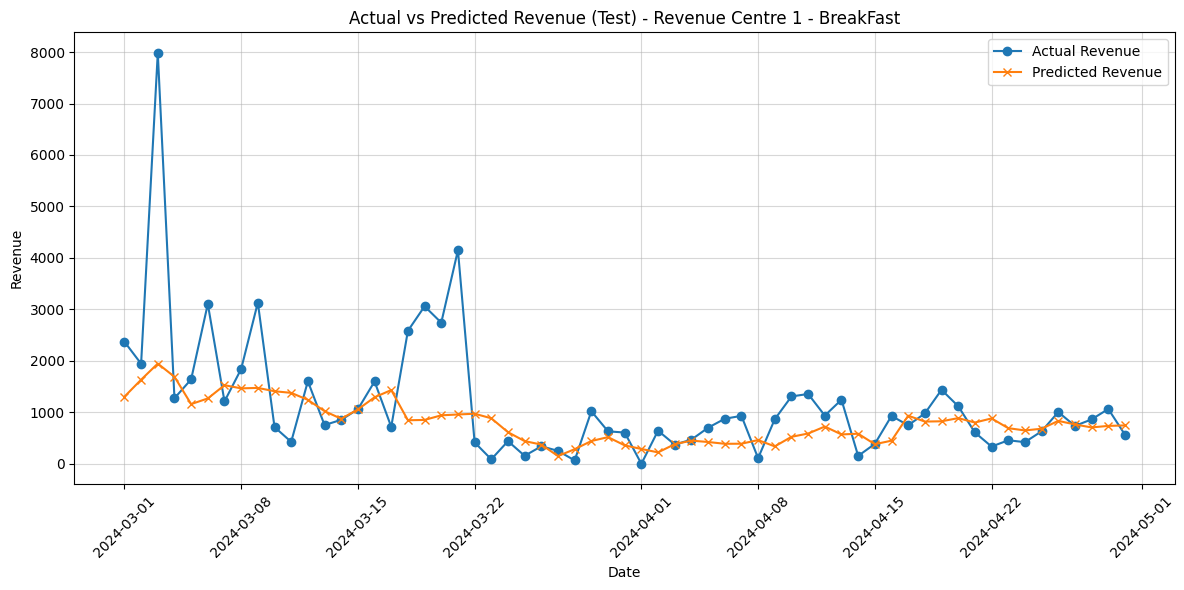

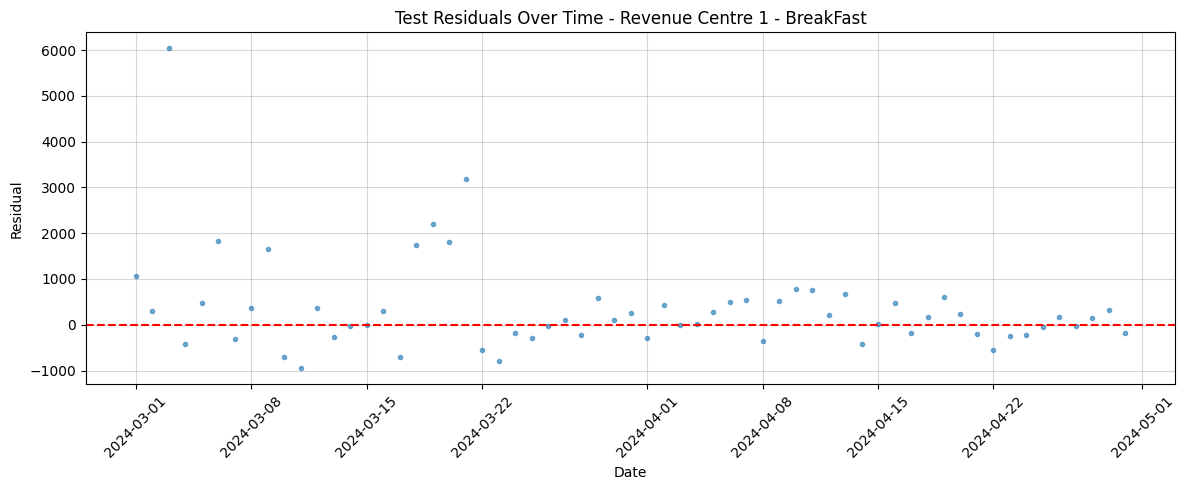


🔎 Manual trial for Revenue Centre 1 - Dinner
Trial with lr=0.0001, units=128, alpha=1.0 → RMSE=1792.03, weights: LSTM=0.290, Ridge=0.710
✅ Using params: LR=0.00010, Units=128, Alpha=1.00, Avg CV RMSE=1792.03
✅ Ensemble weights (CV): LSTM=0.290, Ridge=0.710

--- FINAL TEST RESULTS (Revenue Centre 1 - Dinner) ---
TEST RMSE: 1508.53, TEST MAPE: 40.41%


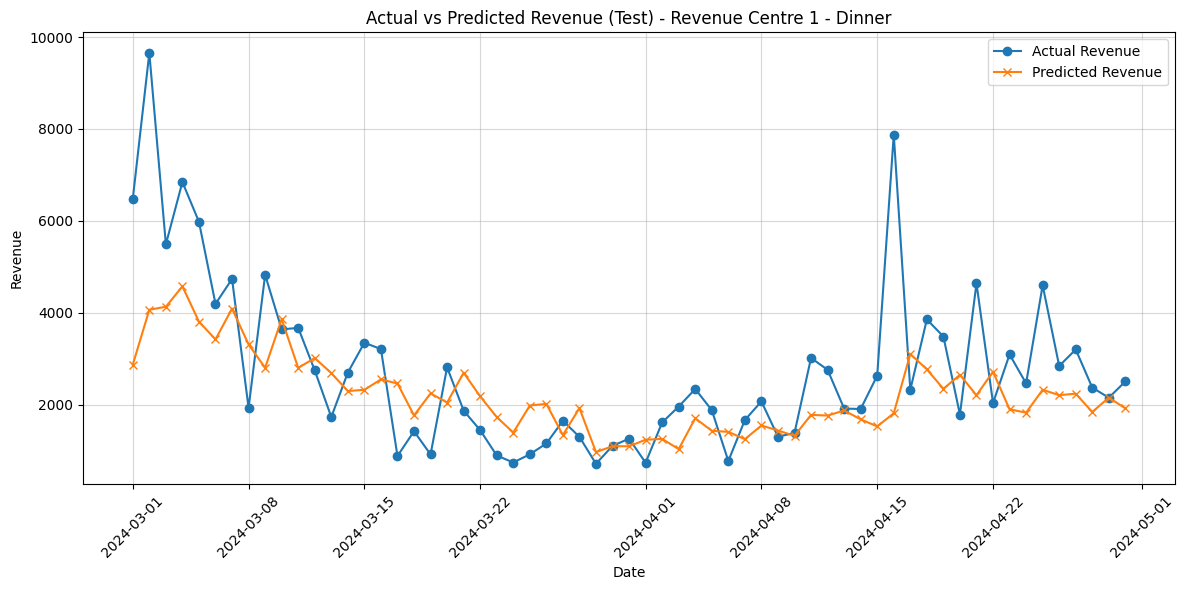

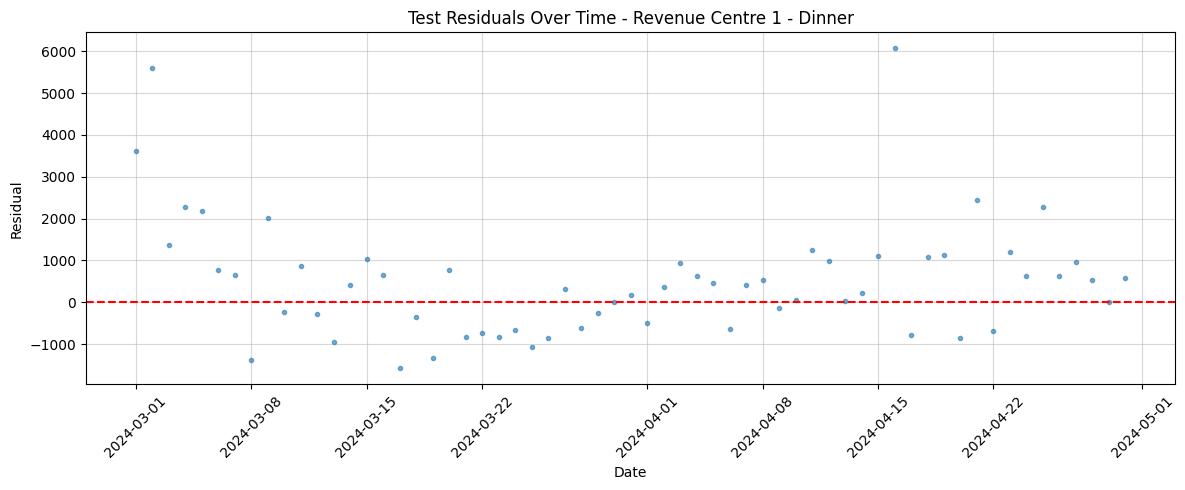


🔎 Manual trial for Revenue Centre 1 - Lunch
Trial with lr=0.0005, units=64, alpha=100.0 → RMSE=848.52, weights: LSTM=0.419, Ridge=0.581
✅ Using params: LR=0.00050, Units=64, Alpha=100.00, Avg CV RMSE=848.52
✅ Ensemble weights (CV): LSTM=0.419, Ridge=0.581

--- FINAL TEST RESULTS (Revenue Centre 1 - Lunch) ---
TEST RMSE: 605.14, TEST MAPE: 1549126909.68%


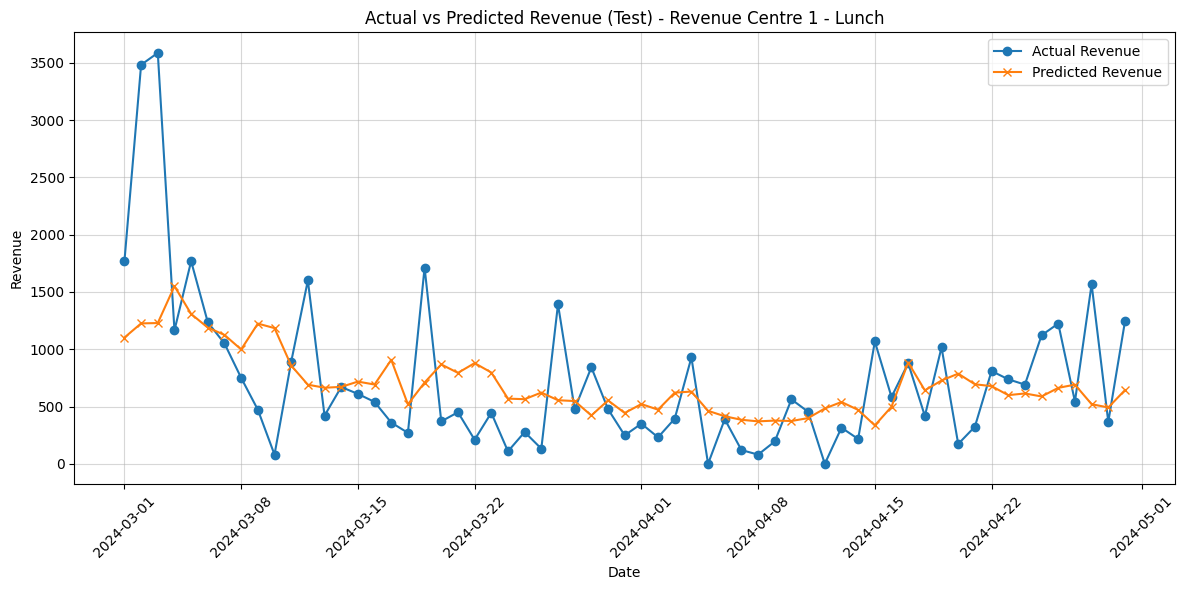

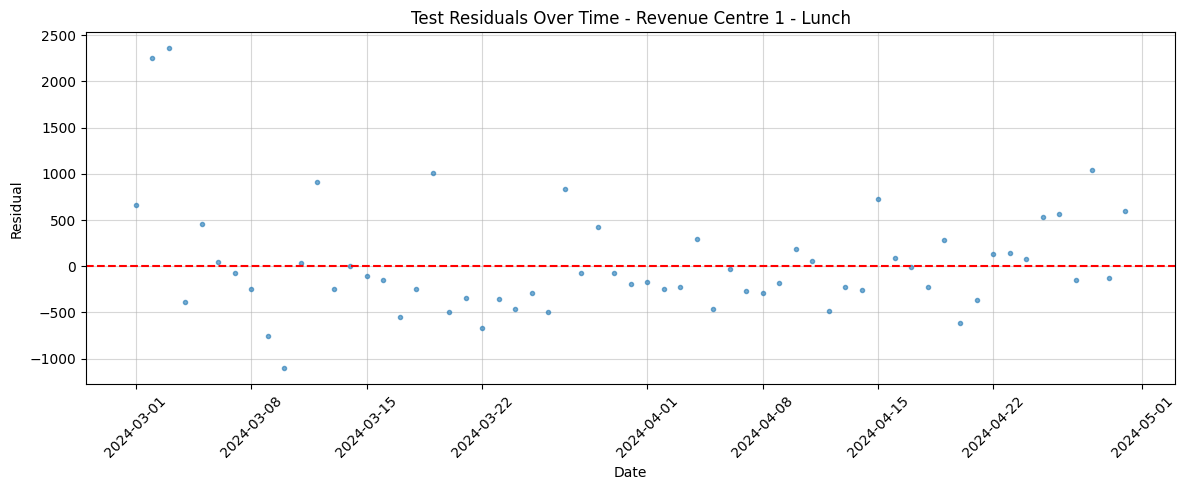


================= Revenue Centre 2 =================

🔎 Manual trial for Revenue Centre 2 - BreakFast
Trial with lr=0.0005, units=64, alpha=10.0 → RMSE=390.65, weights: LSTM=0.466, Ridge=0.534
✅ Using params: LR=0.00050, Units=64, Alpha=10.00, Avg CV RMSE=390.65
✅ Ensemble weights (CV): LSTM=0.466, Ridge=0.534

--- FINAL TEST RESULTS (Revenue Centre 2 - BreakFast) ---
TEST RMSE: 464.19, TEST MAPE: 8389630071.90%


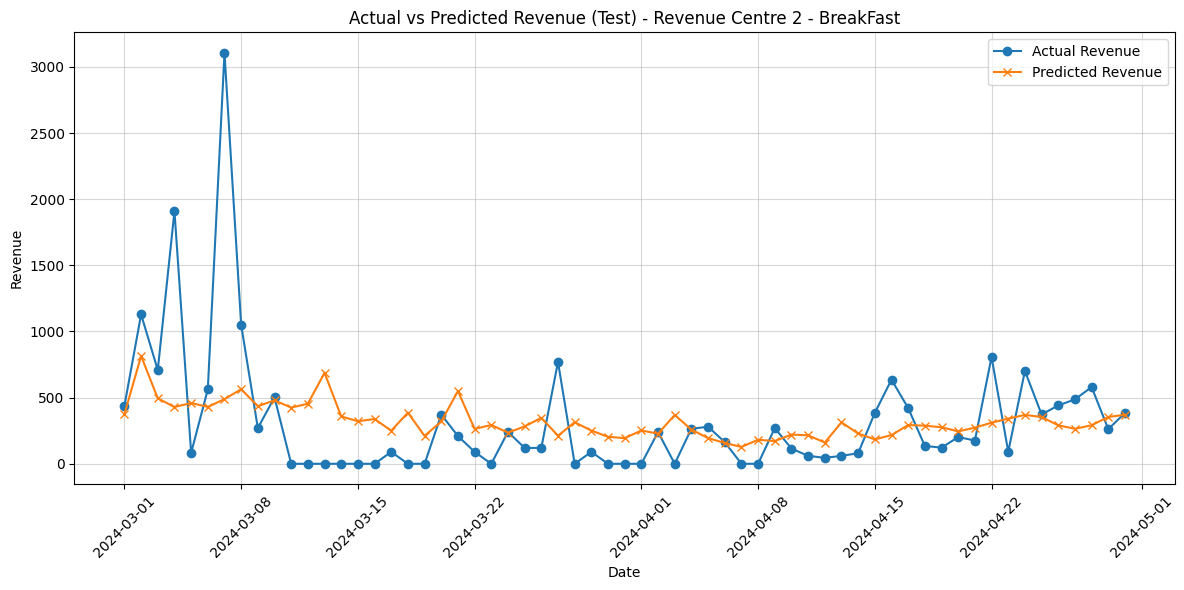

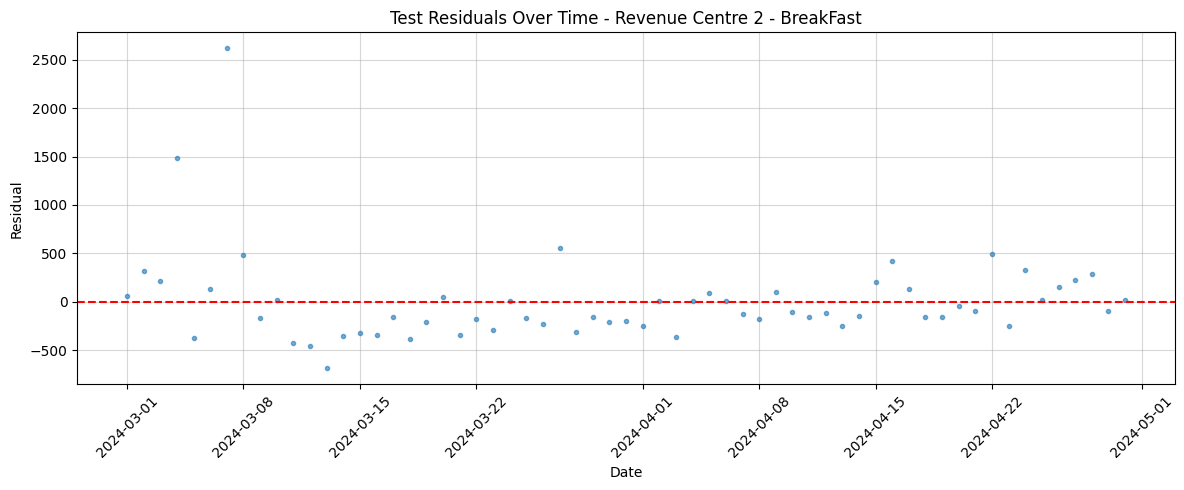


🔎 Manual trial for Revenue Centre 2 - Dinner
Trial with lr=0.0001, units=128, alpha=1.0 → RMSE=943.72, weights: LSTM=0.457, Ridge=0.543
✅ Using params: LR=0.00010, Units=128, Alpha=1.00, Avg CV RMSE=943.72
✅ Ensemble weights (CV): LSTM=0.457, Ridge=0.543

--- FINAL TEST RESULTS (Revenue Centre 2 - Dinner) ---
TEST RMSE: 663.26, TEST MAPE: 5588936699.11%


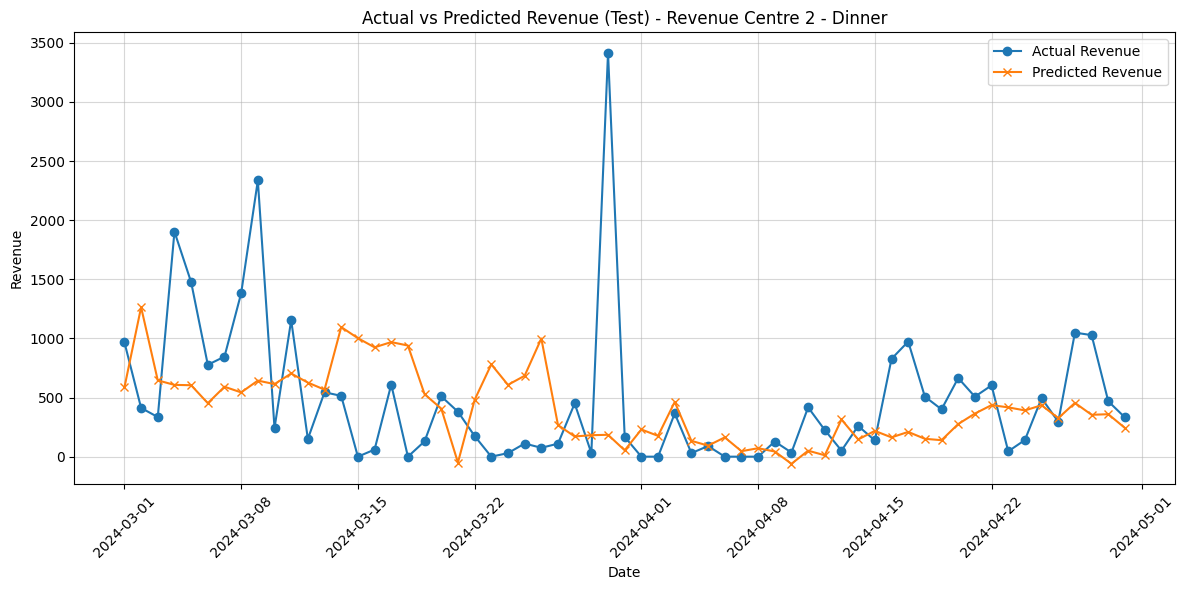

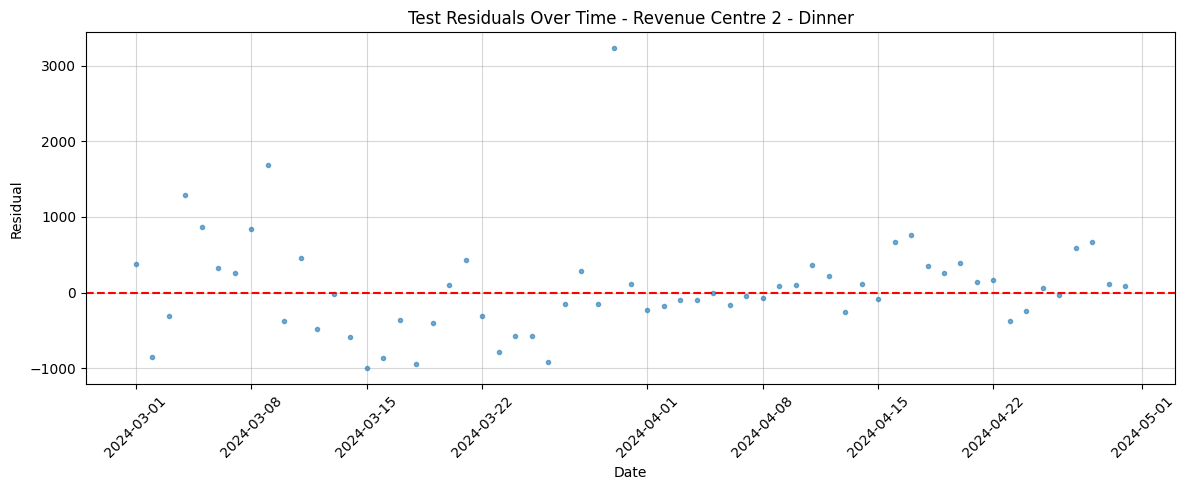


🔎 Manual trial for Revenue Centre 2 - Lunch
Trial with lr=0.0005, units=64, alpha=100.0 → RMSE=469.85, weights: LSTM=0.451, Ridge=0.549
✅ Using params: LR=0.00050, Units=64, Alpha=100.00, Avg CV RMSE=469.85
✅ Ensemble weights (CV): LSTM=0.451, Ridge=0.549

--- FINAL TEST RESULTS (Revenue Centre 2 - Lunch) ---
TEST RMSE: 940.41, TEST MAPE: 3956999062.29%


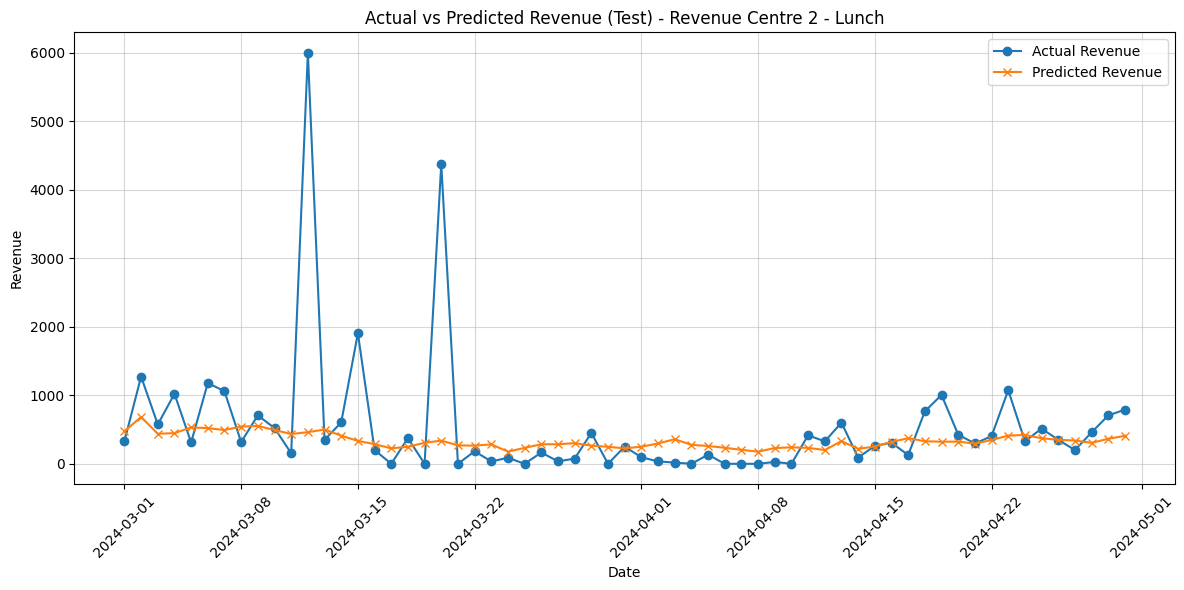

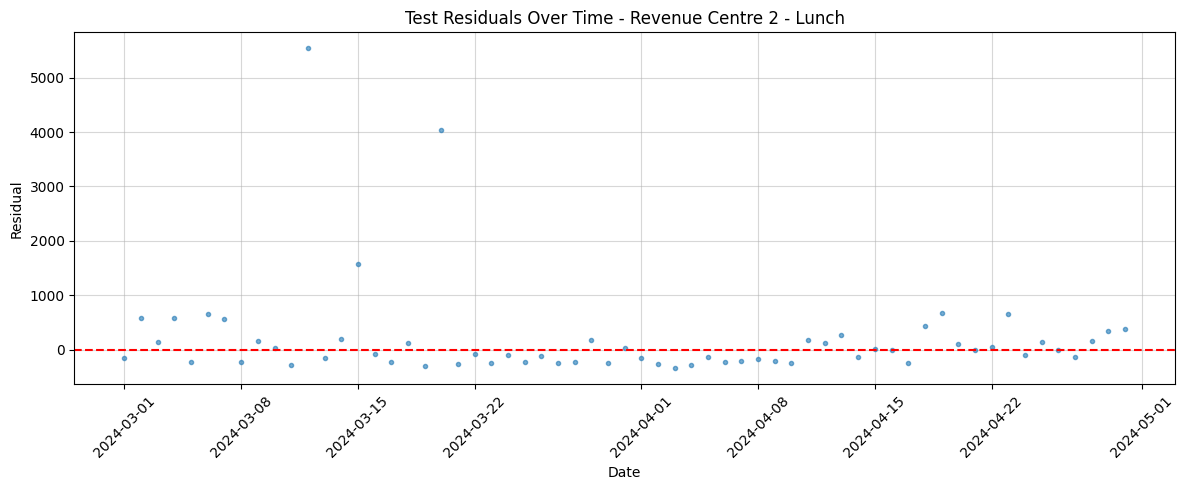

In [27]:
# ================== LOAD CENTERS AND RUN ==================
def load_center_from_excel(file_path, center_sheet_name):
    df = pd.read_excel(file_path, sheet_name=center_sheet_name)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        raise ValueError("Expected a 'Date' column in the sheet.")
    return df

if __name__ == '__main__':
    # Define your manual hyperparameters per target (edit these to probe ranges)
    manual_params = {
        'Revenue_By_BreakFast': {'lr': 0.0005,  'units': 64,  'alpha': 10.0},
        'Revenue_By_Dinner':    {'lr': 0.0001, 'units': 128, 'alpha': 1.0},
        'Revenue_By_Lunch':     {'lr': 0.0005,  'units': 64,  'alpha': 100.0},
    }

    # Example: run one center (sheet index 0). Adjust the range to run multiple centers.
    for center_id in range(0, 2):
        try:
            df_center = load_center_from_excel(INPUT_FILE_NAME, center_id)
            display_name = f"Revenue Centre {center_id+1}"
            print(f"\n================= {display_name} =================")
            train_and_plot_for_center(df_center, display_name, manual_params)
        except Exception as e:
            print(f"⚠️ Skipping {center_id}: {e}")